# Degree Rips bifiltrations

In [1]:
import numpy as np
import gudhi as gd
import multipers as mp
import matplotlib.pyplot as plt

Let start with a noisy dataset, and let's try to recover some topological signal.

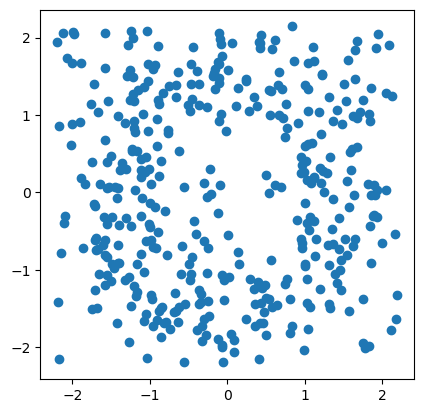

In [2]:
np.random.seed(0)
X = mp.data.noisy_annulus(200,200)
plt.scatter(*X.T);plt.gca().set_aspect(1)

## Definition

Now, if $\mathrm{Rips}_t(X)$ is the Vietoris-Rips filtration at scale $t\ge 0$, then
$\mathrm{DegreeRips}(X)$ is a bifiltration over $\mathbb{R}_+\times \mathbb{N}^{\mathrm{op}}$, defined as follows:

$$\mathrm{DegreeRips}_{r,k}:= \left\{ \sigma \in \mathrm{Rips}_r \mid \forall x\in \sigma,\, \mathrm{degree}(\textnormal{1-skeleton}(\mathrm{Rips}_t(X)),x)\ge k\right\},$$

where given a graph $G$ and a node $n$, $\mathrm{degree}(G,n)$ is the degree of the node $n$ in $G$.
This follows the parameter-free `B-Rips` construction introduced by Lesnick
and Wright {cite:p}`lesnickInteractiveVisualization2D2015`; Blumberg and
Lesnick formalize it as the Degree-Rips bifiltration and prove stability
properties {cite:p}`blumbergStability2ParameterPersistent2024`.

Note that this filtration is **not** 1-critical. See the
[multicritical free implicit resolution notebook](../ops/multicritical_free_implicit_resolution.ipynb)
for the corresponding `one_criticalify` workflow.

TODO : example.

The `DegreeRips` API uses 0-based degree indexing: Python value `j`
corresponds to mathematical threshold `k=j+1`. The `collapse` option below
applies filtration-domination preprocessing
{cite:p}`alonsoFiltrationdominationBifilteredGraphs2023`.

In [18]:
degrees = np.arange(500, dtype=int)
# The associated DegreeRips filtration can be encoded in a (multicritical) simplextree.
st_multi = mp.filtrations.DegreeRips(points = X, ks=degrees,threshold_radius=1.5, collapse=5)

This simplextree `st_multi` only holds the 1-skeleton of this bifiltration. It can be extended, as usual, to a higher dimension complex.

In [19]:
print(len(st_multi))
st_multi.expansion(2)
print(len(st_multi))
st_multi.prune_above_dimension(1)
print(len(st_multi))

4058
22027
4058


## First invariant computation

As shown above expanding simplextree without having access to edge collapse algorithms, or a similar preprocessing step, this is not tractable.

A simple strategy to compute [signed-measure invariants](../invariants/signed_measure.ipynb)
that only rely on 1-d slices is to lazily expand them once they are pushed
forward on a line and 1-d collapsed. This can be achieved using the
`expand_collapse` flag in `mp.signed_measures`.

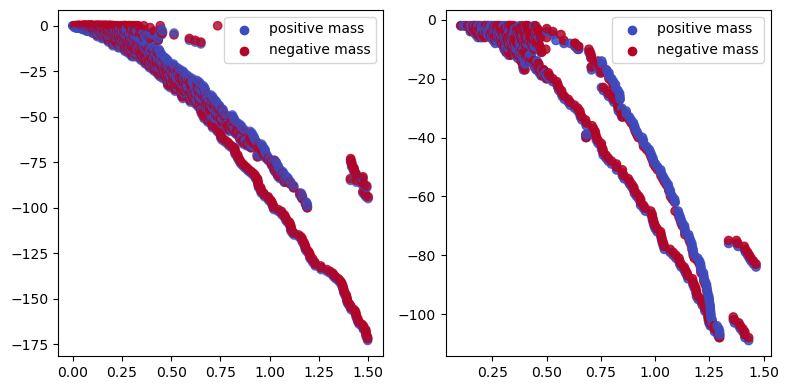

In [7]:
sm0,sm1 = mp.signed_measure(st_multi, degrees=[0,1], invariant="hilbert", plot=True, expand_collapse=True);

The [Hilbert signed measure](../invariants/signed_measure.ipynb) encodes the
[Hilbert function](../invariants/hilbert_function.ipynb), from which we
clearly see the 1-cycle here.

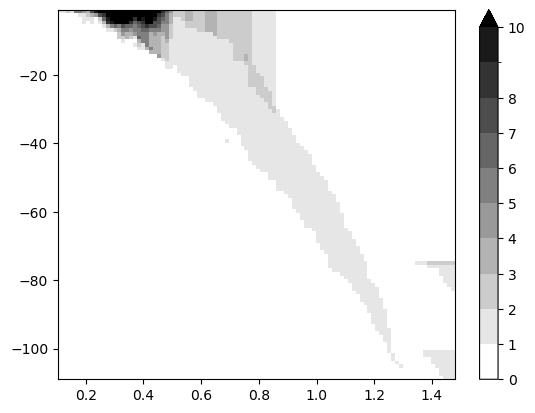

In [8]:
mp.point_measure.integrate_measure(*sm1, plot=True);

## Coarsenning strategies

Invariants that cannot use this strategy cannot be computed in a reasonable time without premilitary preprocessing (WIP) or filtration approximations. Degree 0 is not affected as it doesn't require any expansion.

[MMA computations](../invariants/module_approximation.ipynb) involving a
geometric axis (here Rips) can be computed more efficiently on the `[1,0]`
direction (although the recovery guarantees change), with the second coordinate
swapped (which, in this case, guarantees a "generic initialization").

In [9]:
st_multi.expansion(2)
# mod = mp.module_approximation(mp.Slicer(st_multi, filtration_container="flat"), direction=[1,0], swap_box_coords=[1], from_coordinates=True)
# mod.plot(1)

SimplexTreeMulti[dtype=float64,num_param=2,kcritical=True,is_squeezed=True,max_dim=2]

A first strategy is to approximate the Rips itself, using, e.g., a sparse rips. Note that this is **not** backed up by theoretical guarantees.

In [10]:
import numpy as np
import gudhi as gd
import multipers as mp
import matplotlib.pyplot as plt
X = mp.data.noisy_annulus(500,500)

In [ ]:
# A custom complex (gudhi simplextree) can be put there instead.
st = gd.RipsComplex(points=X, max_edge_length=2,).create_simplex_tree()
st = mp.filtrations.DegreeRips(points=X, threshold_radius=2, ks=np.arange(100, dtype=int), collapse=50)

In [12]:
st_dim2 = st.copy()
st_dim2.expansion(2)
len(st_dim2)

11259

In [13]:
s = mp.Slicer(st_dim2)
# mp.signed_measure(s, degree=1, plot=True)
len(s)

11259

## One-criticalify

Multi-critical filtrations can be represented by one-critical filtrations via
combinatorial presentations
{cite:p}`chacholskiCombinatorialPresentationMultidimensional2017`, then by the
fast free-resolution construction of Bauer et al.
{cite:p}`bauerFastFreeResolutions2026`. For the `multipers` API, see the
[one-criticalification](../ops/multicritical_free_implicit_resolution.ipynb)
and [minimal-presentation](../ops/minimal_presentations_resolutions.ipynb)
notebooks.

In [14]:
one_critical = mp.ops.one_criticalify(s,degree=1)

In [15]:
d1 = one_critical.minpres(1)

In [16]:
box = mp.grids.compute_bounding_box(d1, inflate=1)

In [17]:
len(s)

11259

Preparing filtration (unsqueeze)... Updated  `direction=...`, and `max_error=...` Done.
No box given. Using filtration bounds to infer it.
Using inferred box.
Starting Module Approximation
Num parameters : 2
Box : Box -- Bottom corner : [ -1.74506 -1.74506  ], Top corner : [ 414.745 74.7451  ]
First line basepoint [ 0 0  ]
Initializing mma...
Instantiated 370 summands
 Done ! (0.00153117 s).
Grid size 475 85  Signs [1, 1]
Max error 0.872531
Computing mma...Face 1/2 with grid size 475 0 
Face 2/2 with grid size 0 85 
 Done ! (0.0198472 s).
Cleaning output ... Reevaluating module in filtration grid...Completing output ... Done ! (0.000103125 s).
Done.


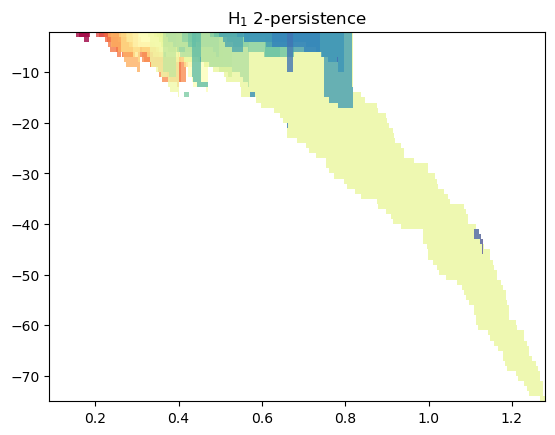

In [18]:
mod = mp.module_approximation(d1, verbose=True,  from_coordinates=True)
mod.plot()

In [47]:
sm, = mp.signed_measure(d1, )
mp.point_measure.integrate_measure(sm, plot=1)

TypeError: integrate_measure() missing 1 required positional argument: 'weights'

## TODOs to make it tractable

WIP